# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================


In [46]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

# ==========================================
# STEP 2: CONFIGURE DEVICE
# ==========================================

In [47]:

IMAGE_SIZE = 28
BATCH_SIZE = 64
VALID_RATIO = 0.1


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3070 Laptop GPU


# ==========================================
# STEP 3: LOAD MNIST DATASET
# ==========================================

In [48]:
# Training transform
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Validation/Test transform
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Full training dataset
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

# Test dataset
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


# ==========================================
# STEP 4: EXPLORE THE DATASET
# ==========================================


In [34]:

# Get one sample
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Image data type:", image.dtype)
print("Label:", label)
print("Pixel value range:", image.min().item(), "to", image.max().item())

Image shape: torch.Size([1, 28, 28])
Image data type: torch.float32
Label: 5
Pixel value range: -0.4242129623889923 to 2.821486711502075


# ==========================================
# STEP 5: CREATE DATALOADERS
# ==========================================


In [35]:
# Split train / validation
train_size = int((1 - VALID_RATIO) * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

# Validation uses test transform
val_dataset.dataset.transform = test_transform

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Train: 54000
Validation: 6000
Test: 10000


# ==========================================
# STEP 6: VISUALIZE SAMPLE IMAGES
# ==========================================


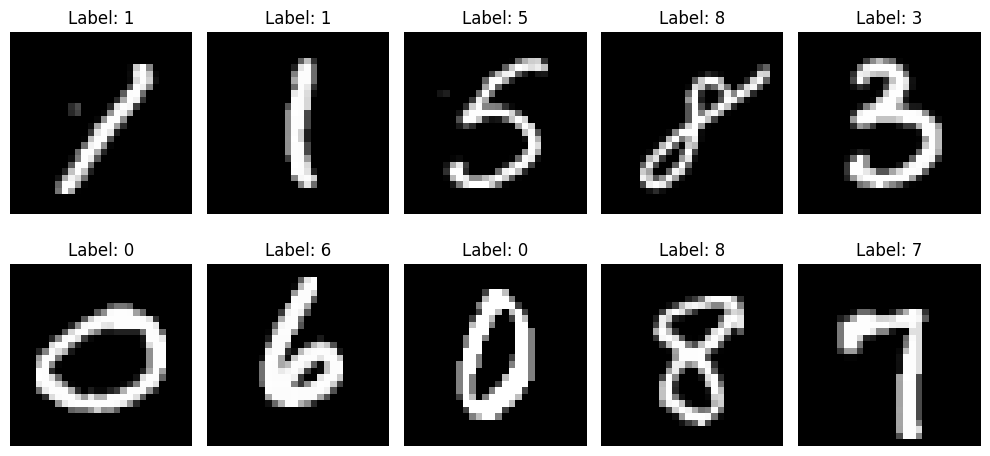

In [36]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================
# STEP 7: BUILD THE CNN MODEL
# ==========================================


In [37]:
class DigitCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # Feature Extraction
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = DigitCNN().to(device)
print(model)

DigitCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


# ==========================================
# STEP 8: DEFINE LOSS FUNCTION & OPTIMIZER
# ==========================================



In [38]:
LEARNING_RATE = 0.001
EPOCHS = 20
PATIENCE = 3

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

print("Training configuration is ready.")

Training configuration is ready.


# ==========================================
# STEP 9: TRAIN THE MODEL
# ==========================================


In [39]:
from pathlib import Path
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

# ------------------------------------------
# MODEL SAVE PATH
# ------------------------------------------

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "best_digit_cnn.pth"

print(f"Best model will be saved to: {MODEL_PATH}")


# ------------------------------------------
# TRAINING VARIABLES
# ------------------------------------------

best_val_loss = float("inf")
early_counter = 0


# ------------------------------------------
# TRAINING LOOP
# ------------------------------------------

for epoch in range(EPOCHS):

    # =========================
    # TRAINING
    # =========================

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        # Move data to CPU/GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Accumulate loss
        train_loss += loss.item()

        # Get predictions
        preds = outputs.argmax(dim=1)

        # Calculate accuracy
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    # Average training loss
    train_loss /= len(train_loader)

    # Training accuracy
    train_acc = 100 * train_correct / train_total


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            # Move data to CPU/GPU
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Accumulate validation loss
            val_loss += loss.item()

            # Get predictions
            preds = outputs.argmax(dim=1)

            # Calculate accuracy
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    # Average validation loss
    val_loss /= len(val_loader)

    # Validation accuracy
    val_acc = 100 * val_correct / val_total


    # =========================
    # SAVE TRAINING HISTORY
    # =========================

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)


    # =========================
    # LEARNING RATE SCHEDULER
    # =========================

    scheduler.step(val_loss)


    # =========================
    # SAVE BEST MODEL
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        early_counter = 0

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print(
            f"Best model saved → {MODEL_PATH}"
        )

    else:

        early_counter += 1


    # =========================
    # DISPLAY EPOCH RESULTS
    # =========================

    print(
        f"Epoch {epoch + 1:02}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )


    # =========================
    # EARLY STOPPING
    # =========================

    if early_counter >= PATIENCE:

        print("Early stopping activated.")
        break

Best model will be saved to: ..\models\best_digit_cnn.pth
Best model saved → ..\models\best_digit_cnn.pth
Epoch 01/20 | Train Loss: 0.1694 | Train Acc: 94.84% | Val Loss: 0.0503 | Val Acc: 98.40%
Best model saved → ..\models\best_digit_cnn.pth
Epoch 02/20 | Train Loss: 0.0692 | Train Acc: 97.93% | Val Loss: 0.0446 | Val Acc: 98.80%
Best model saved → ..\models\best_digit_cnn.pth
Epoch 03/20 | Train Loss: 0.0571 | Train Acc: 98.26% | Val Loss: 0.0434 | Val Acc: 98.80%
Best model saved → ..\models\best_digit_cnn.pth
Epoch 04/20 | Train Loss: 0.0463 | Train Acc: 98.57% | Val Loss: 0.0400 | Val Acc: 98.80%
Best model saved → ..\models\best_digit_cnn.pth
Epoch 05/20 | Train Loss: 0.0394 | Train Acc: 98.81% | Val Loss: 0.0365 | Val Acc: 98.90%
Best model saved → ..\models\best_digit_cnn.pth
Epoch 06/20 | Train Loss: 0.0340 | Train Acc: 98.93% | Val Loss: 0.0272 | Val Acc: 99.22%
Epoch 07/20 | Train Loss: 0.0298 | Train Acc: 99.03% | Val Loss: 0.0395 | Val Acc: 99.07%
Epoch 08/20 | Train Loss

# ==========================================
# STEP 10: EVALUATE THE MODEL
# ==========================================


In [40]:
# ==========================================
# PHASE 5: PROFESSIONAL MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------
# 1. LOAD BEST MODEL
# ------------------------------------------

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.to(device)
model.eval()


# ------------------------------------------
# 2. RUN TEST SET
# ------------------------------------------

test_loss = 0.0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        # Move data to CPU/GPU
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        # Get predictions
        predictions = outputs.argmax(dim=1)

        # Store predictions and true labels
        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


# ------------------------------------------
# 3. CONVERT TO NUMPY ARRAYS
# ------------------------------------------

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)


# ------------------------------------------
# 4. TEST LOSS
# ------------------------------------------

test_loss = test_loss / len(test_loader)


# ------------------------------------------
# 5. TEST ACCURACY
# ------------------------------------------

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)


# ------------------------------------------
# 6. PRECISION
# ------------------------------------------

precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)


# ------------------------------------------
# 7. RECALL
# ------------------------------------------

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)


# ------------------------------------------
# 8. F1 SCORE
# ------------------------------------------

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)


# ------------------------------------------
# 9. DISPLAY MAIN RESULTS
# ------------------------------------------

print("=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy * 100:.2f}%")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1 Score : {f1:.4f}")

print("=" * 50)

C:\Users\hp\AppData\Local\Temp\ipykernel_13124\206129892.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


MODEL EVALUATION RESULTS
Test Loss      : 0.0284
Test Accuracy  : 99.15%
Macro Precision: 0.9915
Macro Recall   : 0.9913
Macro F1 Score : 0.9914


### CLASSIFICATION REPORT

In [41]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=[str(i) for i in range(10)],
    digits=4
)

print(report)

              precision    recall  f1-score   support

           0     0.9929    0.9949    0.9939       980
           1     0.9921    0.9991    0.9956      1135
           2     0.9961    0.9932    0.9947      1032
           3     0.9844    0.9980    0.9912      1010
           4     0.9969    0.9919    0.9944       982
           5     0.9877    0.9877    0.9877       892
           6     0.9947    0.9885    0.9916       958
           7     0.9855    0.9951    0.9903      1028
           8     0.9907    0.9867    0.9887       974
           9     0.9940    0.9782    0.9860      1009

    accuracy                         0.9915     10000
   macro avg     0.9915    0.9913    0.9914     10000
weighted avg     0.9915    0.9915    0.9915     10000



### CONFUSION MATRIX

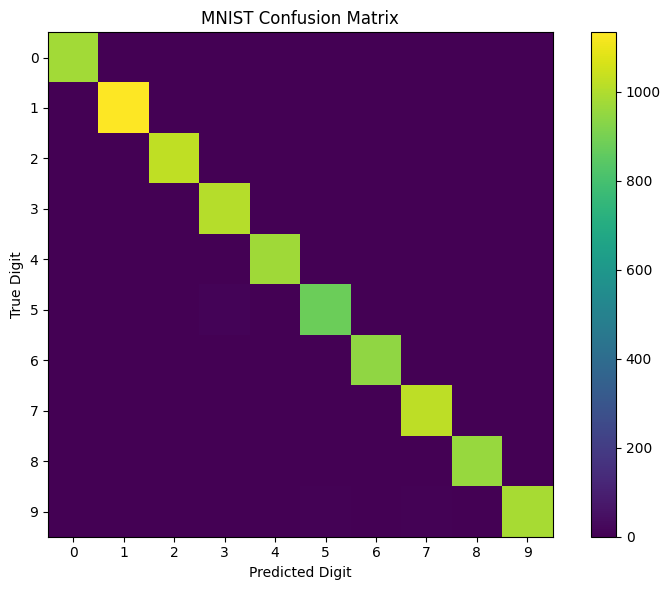

In [42]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("MNIST Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")

plt.xticks(range(10))
plt.yticks(range(10))

plt.colorbar()

plt.tight_layout()
plt.show()

### ERROR ANALYSIS

In [43]:

incorrect_images = []
incorrect_labels = []
incorrect_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        incorrect = predictions != labels

        incorrect_images.extend(
            images[incorrect].cpu()
        )

        incorrect_labels.extend(
            labels[incorrect].cpu()
        )

        incorrect_predictions.extend(
            predictions[incorrect].cpu()
        )


print("Incorrect predictions:", len(incorrect_images))

Incorrect predictions: 85


### VISUALIZE INCORRECT PREDICTIONS

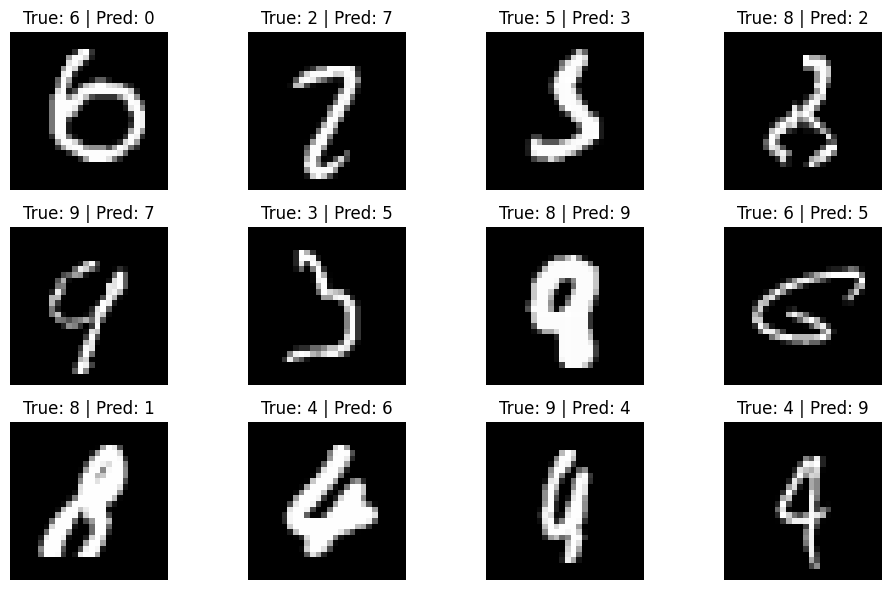

In [44]:
plt.figure(figsize=(10, 6))

num_images = min(12, len(incorrect_images))

for i in range(num_images):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        incorrect_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"True: {incorrect_labels[i].item()} | "
        f"Pred: {incorrect_predictions[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================
# STEP 11 : INFERENCE & PREDICTION
# ==========================================


C:\Users\hp\AppData\Local\Temp\ipykernel_13124\1743630242.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Best model loaded successfully.


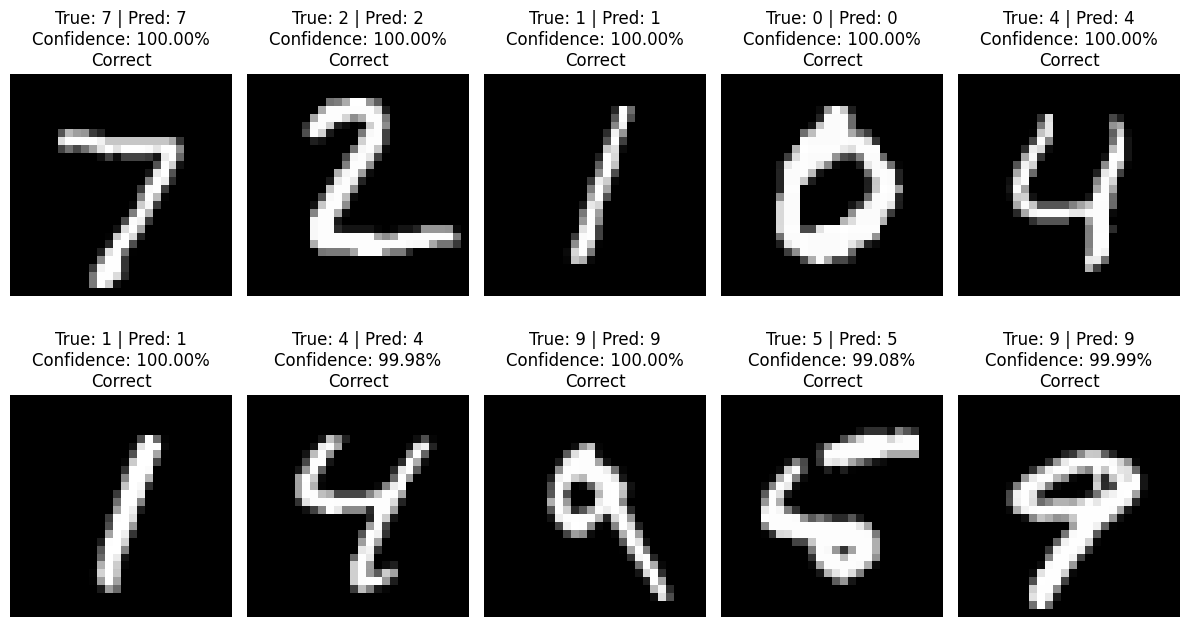

In [45]:
import torch
import matplotlib.pyplot as plt


# ------------------------------------------
# 1. LOAD BEST MODEL
# ------------------------------------------

inference_model = DigitCNN().to(device)

inference_model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

inference_model.eval()

print("Best model loaded successfully.")


# ------------------------------------------
# 2. GET A BATCH OF TEST IMAGES
# ------------------------------------------

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)


# ------------------------------------------
# 3. MAKE PREDICTIONS
# ------------------------------------------

with torch.inference_mode():

    outputs = inference_model(images)

    # Convert logits into probabilities
    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    # Get predicted class
    predictions = probabilities.argmax(
        dim=1
    )

    # Get confidence of predicted class
    confidence = probabilities.max(
        dim=1
    ).values


# ------------------------------------------
# 4. DISPLAY PREDICTIONS
# ------------------------------------------

plt.figure(figsize=(12, 7))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    # Display image
    plt.imshow(
        images[i].cpu().squeeze(),
        cmap="gray"
    )

    true_label = labels[i].item()
    predicted_label = predictions[i].item()
    confidence_score = confidence[i].item() * 100

    # Check prediction
    if true_label == predicted_label:
        result = "Correct"
    else:
        result = "Incorrect"

    plt.title(
        f"True: {true_label} | "
        f"Pred: {predicted_label}\n"
        f"Confidence: {confidence_score:.2f}%\n"
        f"{result}"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()